# 03.10.26 Выбор набора данных для разработки пробной схемы Петри



| Набор данных | События | Плюсы  | Минусы  |
|---|---|---|---|
| Sepsis Cases | Регистрация, триаж, анализы, внутривенные антибиотики и жидкость, поступление в отделение, выписка и возвращение для продолжения лечения. Есть время событий и некоторые результаты анализов | Уже готовый журнал событий. Можно проследить отдельные случаи и построить сеть петри. Всего 16 типов событий  | Нельзя определить смерть по категориям Release A–E. События иногда имеют одинаковое время. Окончание записи не всегда означает завершение лечения |
| BPI Challenge 2011 - Hospital Log | Подробный журнал больничных действий: исследования, процедуры и другие записи. Есть время, коды действий, подразделения и некоторые сведения о случаях | Много событий и длинных траекторий. Можно рассмотреть повторения и разные варианты процесса | Сотни типов событий, много названий на голландском и служебных кодов. Сложно получить простую понятную схему. Нет готовой отметки о смерти |
| PhysioNet/CinC Challenge 2012 | Повторные измерения за первые 48 часов в реанимации: пульс, давление, температура, анализы и другие показатели. Есть возраст, пол и некоторые начальные характеристики. Данные об исходах в отдельных файлах | Видно, как меняется состояние пациента. Можно использовать показатели для прогноза исхода | Журнал измерений, но не готовая последовательность лечебных действий. События для сети нужно определить самостоятельно48 часов измерений не равны всему времени наблюдения за пациентом|
| PhysioNet Challenge 2019 | Почасовые показатели пациентов в реанимации и метка сепсиса. Есть жизненные показатели, анализы и некоторые сведения о пациенте | Удобно изучать изменения состояния и прогнозировать сепсис. Измерения представлены по часам | Нет готового подробного журнала лечения. Много пропущенных значений |
| Heart Failure Clinical Records | Одна строка на пациента: возраст, пол, заболевания, результаты некоторых анализов, длительность наблюдения и отметка о смерти | Небольшая и понятная таблица. Есть данные для анализа времени до смерти | Всего 299 пациентов. Нет последовательности обследований и лечения, поэтому сеть петри не построить |
| Hospital Billing | События обработки больничных счетов: регистрация, проверки и другие административные действия. | Готовый журнал| Описывает работу со счетами, а не путь обследования и лечения пациента |
|НУЖЕН ДОСТУП:||||
| eICU-CRD | Несколько связанных таблиц: пребывания в реанимации, показатели состояния, анализы, диагнозы, лекарства, лечение и информация о завершении пребывания. Время часто указано в минутах от поступления в реанимацию | Можно соединить траекторию лечения с показателями и исходом. Много пациентов из разных больниц | Нужен доступ. Нужно объединять таблицы и выбирать события |
| MIMIC-IV | Данные о пациентах, госпитализациях, переводах между отделениями, анализах, лекарствах и процедурах. Есть информация о смерти с ограничениями периода наблюдения | Подробные данные для построения траекторий и анализа исходов | Нужен доступ. Очень много данных скорее всего |



Для первого этапа выбрала Sepsis Cases - в нём уже есть понятные медицинские события и их время. Для дальнейшей работы со смертью как исходом можно рассмотреть eICU-CRD или MIMIC-IV

# 06.10.26 Начало работы с Sepsis Cases

Sepsis Cases - Event Log.xes. Сначала открыла его в ProM Lite и построила сеть Петри с помощью Inductive Miner. Использовала вариант infrequent с порогом шума 0,20. Не особо понравилась построенная визуализация, но помогло посмотреть, какие события вообще есть

Подготовка таблицы событий:
Изначальный журнал событий смотреть в форма XES неудобно, поэтому написала код для преобразования XES в XLSX. XLSX выбрала, тк у меня китайская винда и WPS Office, и он каждый раз преобразует некоторые дробные значения в даты... А менять в ручную муторно. Каждое событие сохраняется отдельной строкой вместе с идентификатором случая, названием, временем и дополнительными полями (их немало)

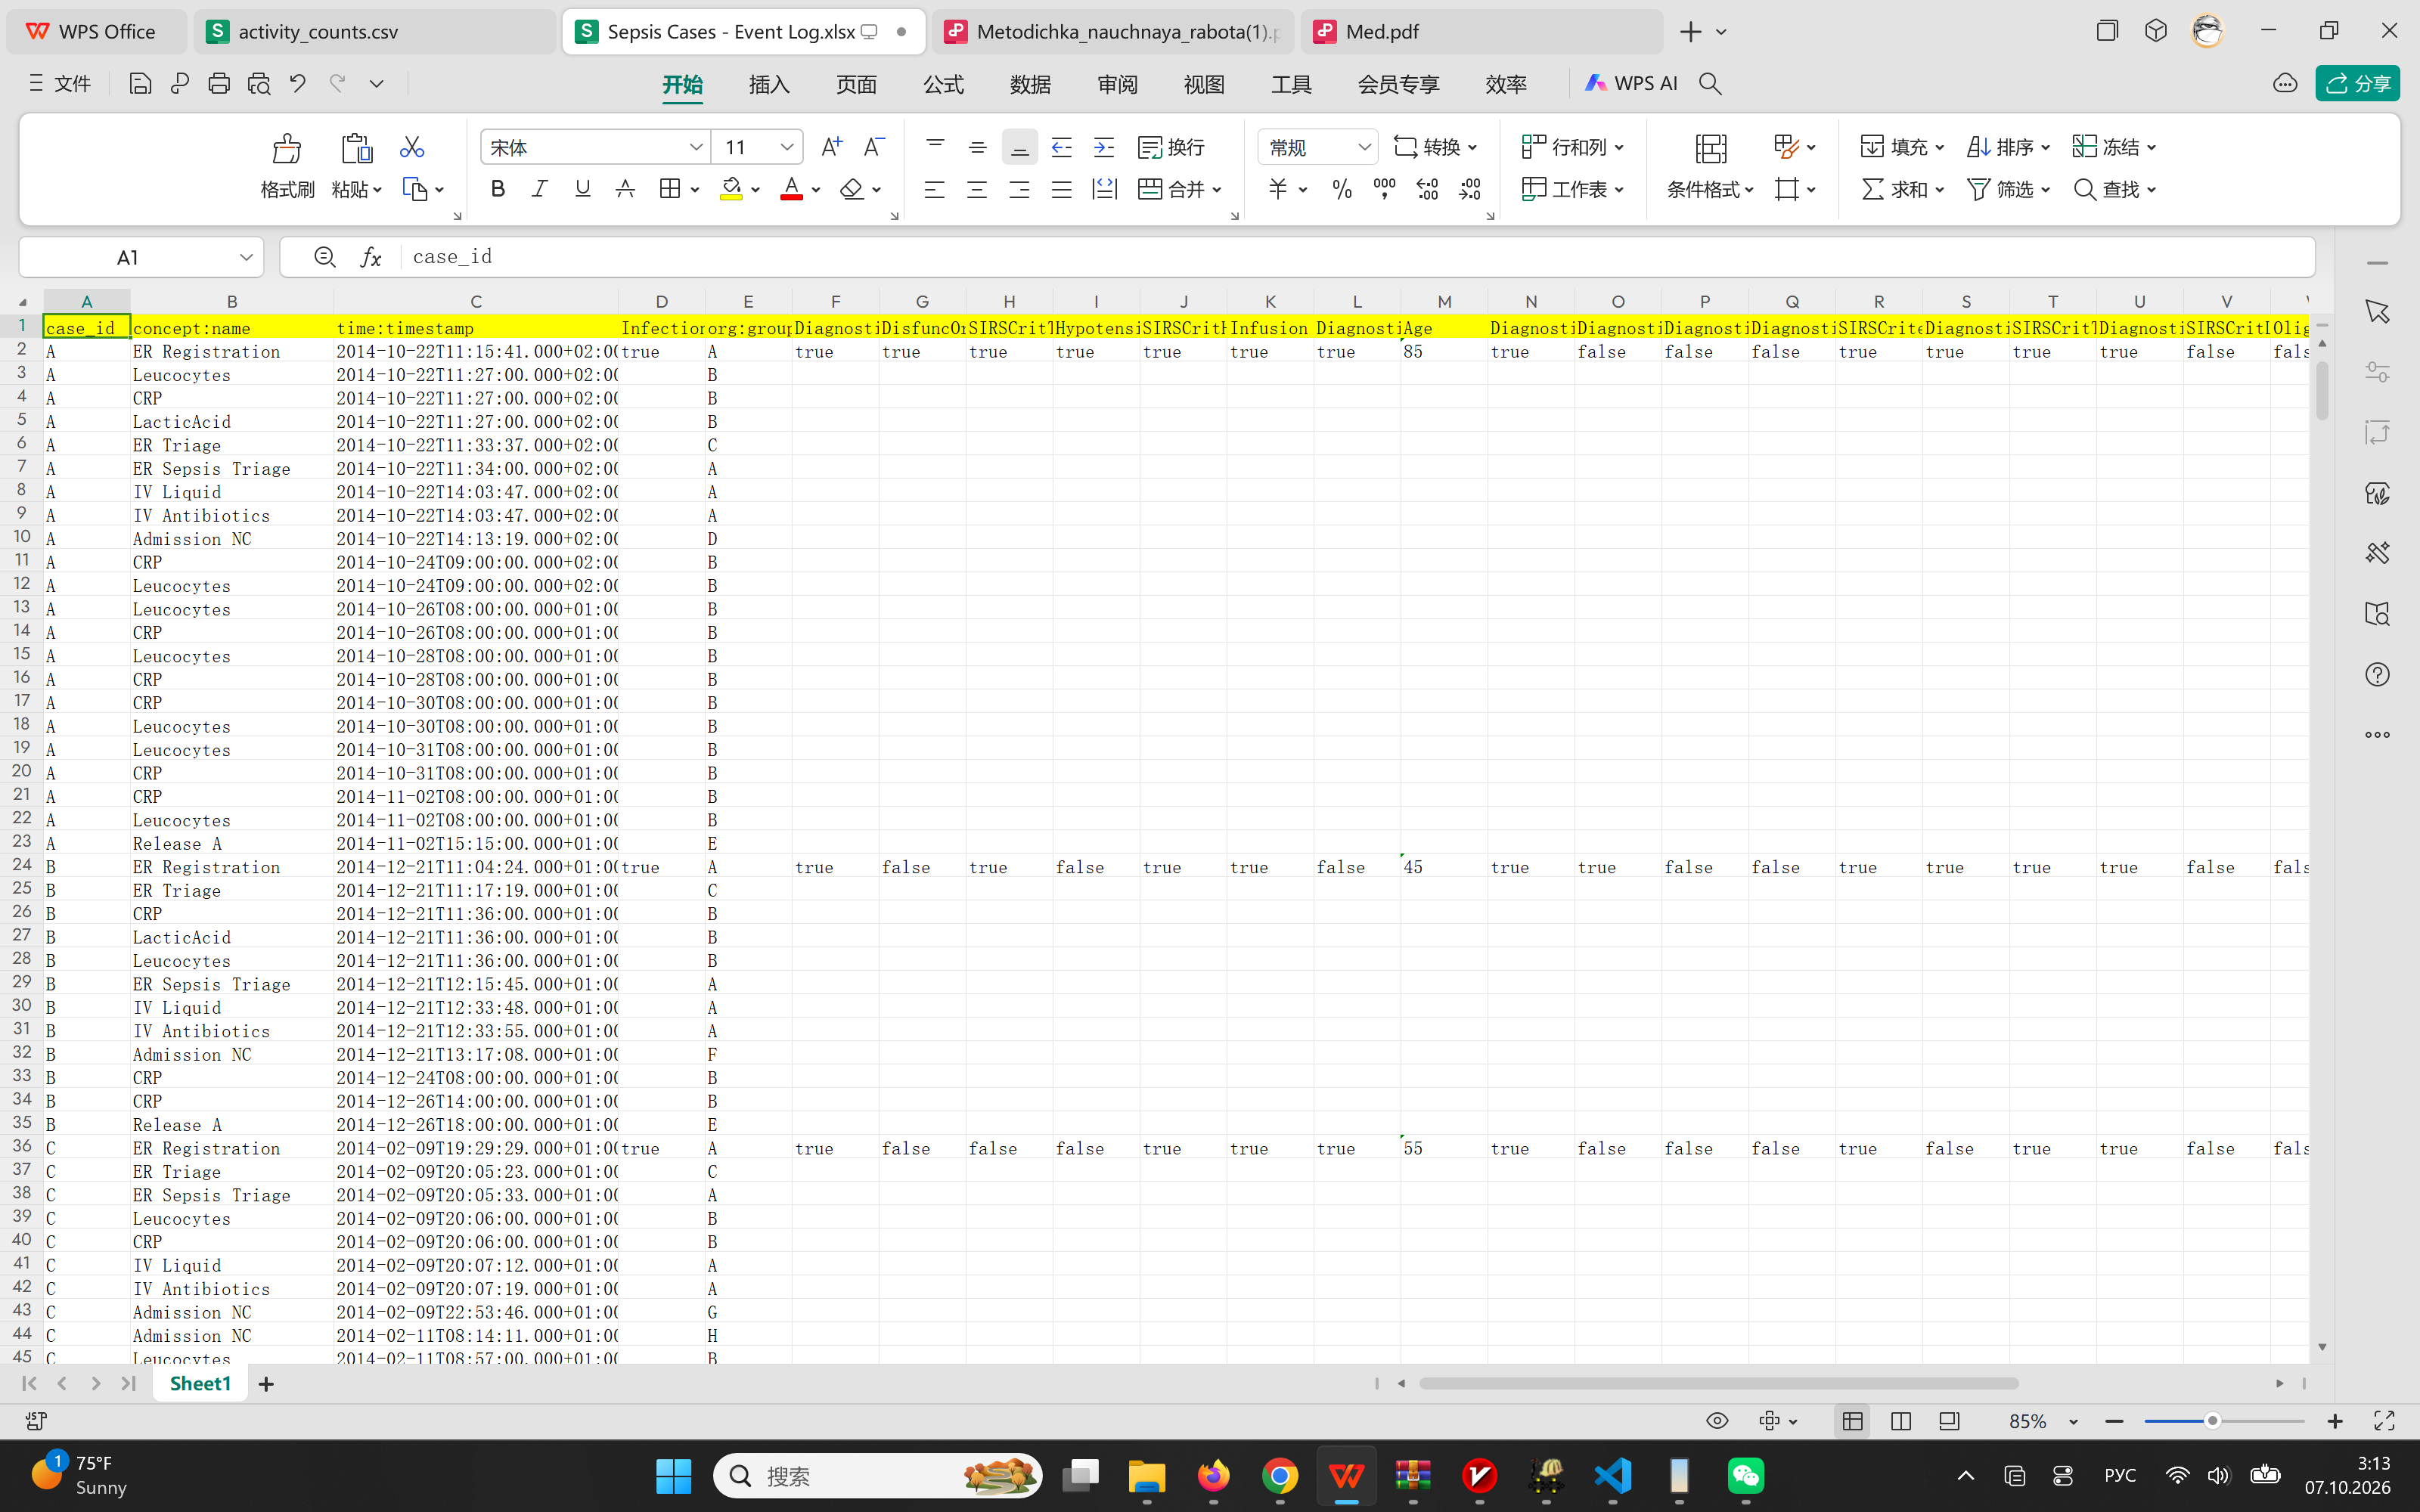



# 07.10.26 
  
Первичный анализ:
Посмотрела отдельные случаи, подсчитала количество событий и случаев, частоты разных событий и количество случаев, в которых они встречаются. Отдельно посмотрела, какими событиями начинаются и заканчиваются траектории

Рассчитала время между первой и последней записью каждого случая, посмотрела статистику длительности и самые длинные траектории

In [4]:
import pandas as pandas
import xml.etree.ElementTree as element_tree
from pathlib import Path



file_path = Path(r"D:\Универ\4 курс\Диплом\Sepsis Cases - Event Log.xes")

file_extension = file_path.suffix
file_extension = file_extension.lower()


if file_extension == ".csv":
    column_separator = ","

    events_table = pandas.read_csv(
        file_path,
        sep=column_separator,
        dtype=str,
        encoding="utf-8-sig"
    )

elif file_extension == ".xes":

    xml_document = element_tree.parse(file_path)
    root_element = xml_document.getroot()

    # Убираем пространство имён из названий XML-элементов
    for xml_element in root_element.iter():

        tag_parts = xml_element.tag.split("}")
        tag_without_namespace = tag_parts[-1]

        xml_element.tag = tag_without_namespace

    event_rows = []
    traces = root_element.findall("trace")

    for trace in traces:
        current_case_identifier = None

        #id
        for trace_attribute in trace:
            attribute_name = trace_attribute.get("key")

            if attribute_name == "concept:name":
                current_case_identifier = trace_attribute.get("value")

        if current_case_identifier is None:

            raise ValueError(
                "Где-то отсутствует id"
            )

        #события текущего случая
        events = trace.findall("event")

        for event in events:
            event_information = {}

            for event_attribute in event:
                attribute_name = event_attribute.get("key")
                attribute_value = event_attribute.get("value")

                if attribute_name is not None:
                    event_information[attribute_name] = attribute_value

            event_information["case_id"] = current_case_identifier

            event_rows.append(event_information)

    #список строк в таблицу
    events_table = pandas.DataFrame(event_rows)

else:
    raise ValueError(
        "Неподдерживаемый формат. Нужен файл .csv или .xes"
    )


required_columns = [
    "case_id",
    "concept:name",
    "time:timestamp"
]

missing_columns = []

for column_name in required_columns:
    if column_name not in events_table.columns:
        missing_columns.append(column_name)

if len(missing_columns) > 0:
    raise ValueError(
        f"В таблице отсутствуют столбцы: {missing_columns}"
    )

if events_table.empty:
    raise ValueError("В файле нет событий")


#Пропуски в необходимых столбцах
required_information = events_table[required_columns]
missing_values = required_information.isna()
columns_with_missing_values = missing_values.any()
has_missing_values = columns_with_missing_values.any()

if has_missing_values:
    raise ValueError(
        "Есть события без идентификатора случая, названия или времени"
    )


#Время из текста в даты
event_timestamps = events_table["time:timestamp"]

converted_timestamps = pandas.to_datetime(
    event_timestamps,
    format="mixed",
    utc=True,
    errors="raise"
)

events_table["time:timestamp"] = converted_timestamps


#Подсчёт случаев и событий
number_of_events = len(events_table)
case_identifiers = events_table["case_id"]
number_of_cases = case_identifiers.nunique()

print("Количество событий:", number_of_events)
print("Количество случаев:", number_of_cases)


# #Вывод единичного случая
# unique_case_identifiers = case_identifiers.drop_duplicates()
# selected_case_identifier = unique_case_identifiers.iloc[1049]

# rows_of_selected_case = (
#     case_identifiers == selected_case_identifier
# )

# selected_case_events = events_table[rows_of_selected_case]
# selected_case_table = selected_case_events.copy()


# #Сортировка событий по времени
# selected_case_table = selected_case_table.sort_values(
#     by="time:timestamp",
#     kind="stable"
# )

# columns_to_display = [
#     "case_id",
#     "concept:name",
#     "time:timestamp"
# ]

# selected_case_display = selected_case_table[columns_to_display]
# number_of_selected_case_events = len(selected_case_table)

# selected_case_text = selected_case_display.to_string(
#     index=False
# )

# print()
# print("Случай:", selected_case_identifier)
# print("Количество событий в случае:", number_of_selected_case_events)
# print(selected_case_text)




#Количество разных видов событий
event_names = events_table["concept:name"]

number_of_event_types = event_names.nunique()
print()
print("Количество видов событий:", number_of_event_types)

event_counts = event_names.value_counts()

print()
print("Количество событий каждого вида (в общем):")
print(event_counts.to_string())




#Убираем повторения событий в одном случае, чтобы посмотреть, какие чаще всего встречаются в траекториях
columns_for_counting = [
    "case_id",
    "concept:name"
]

case_event_pairs = events_table[columns_for_counting]

unique_case_event_pairs = case_event_pairs.drop_duplicates()
event_names_in_cases = unique_case_event_pairs["concept:name"]
number_of_cases_with_event = event_names_in_cases.value_counts()

print()
print("Количество случаев, в которых встречается событие:")
print(number_of_cases_with_event.to_string())





#Сортировка таблицы сначала по случаю, затем по времени
sorting_columns = [
    "case_id",
    "time:timestamp"
]

sorted_events_table = events_table.sort_values(
    by=sorting_columns,
    kind="stable"
)

#Группы по айдишнику
case_groups = sorted_events_table.groupby("case_id")

first_events_table = case_groups.head(1)
last_events_table = case_groups.tail(1)

first_event_names = first_events_table["concept:name"]
first_event_counts = first_event_names.value_counts()

last_event_names = last_events_table["concept:name"]
last_event_counts = last_event_names.value_counts()

print()
print("Первые события случаев:")
print(first_event_counts.to_string())

print()
print("Последние события случаев:")
print(last_event_counts.to_string())





#Длительность каждого случая
first_events_by_case = first_events_table.set_index("case_id")
last_events_by_case = last_events_table.set_index("case_id")

case_start_times = first_events_by_case["time:timestamp"]
case_end_times = last_events_by_case["time:timestamp"]

case_durations = case_end_times - case_start_times

case_durations_in_seconds = case_durations.dt.total_seconds()
seconds_in_one_day = 24 * 60 * 60
case_durations_in_days = (
    case_durations_in_seconds / seconds_in_one_day
)

case_summary_table = pandas.DataFrame()

case_summary_table["start_time"] = case_start_times
case_summary_table["end_time"] = case_end_times
case_summary_table["duration_days"] = case_durations_in_days

#Первые десять случаев
first_ten_cases = case_summary_table.head(10)

print()
print("Длительность случаев в днях:")
print(first_ten_cases.to_string())

#Общая статистика длительности
duration_statistics = case_durations_in_days.describe()

print()
print("Статистика длительности:")
print(duration_statistics.to_string())





#Cлучаи от длинного к короткому
cases_sorted_by_duration = case_summary_table.sort_values(
    by="duration_days",
    ascending=False
)

#Первые пять строк
five_longest_cases = cases_sorted_by_duration.head(5)

print()
print("Пять самых длинных случаев:")
print(five_longest_cases.to_string())


sorted_case_identifiers = cases_sorted_by_duration.index
longest_case_identifier = sorted_case_identifiers[0]
event_case_identifiers = sorted_events_table["case_id"]

rows_of_longest_case = (
    event_case_identifiers == longest_case_identifier
)

longest_case_events = sorted_events_table[rows_of_longest_case]
longest_case_table = longest_case_events.copy()

#Время между соседними событиями
event_times = longest_case_table["time:timestamp"]

time_between_events = event_times.diff()

time_between_events_in_seconds = (
    time_between_events.dt.total_seconds()
)

time_between_events_in_days = (
    time_between_events_in_seconds / seconds_in_one_day
)

longest_case_table["days_since_previous_event"] = (
    time_between_events_in_days
)

columns_to_display = [
    "concept:name",
    "time:timestamp",
    "days_since_previous_event"
]

longest_case_display = longest_case_table[columns_to_display]

print()
print("Самый длинный случай:", longest_case_identifier)
print(longest_case_display.to_string(index=False))

Количество событий: 15214
Количество случаев: 1050

Количество видов событий: 16

Количество событий каждого вида (в общем):
concept:name
Leucocytes          3383
CRP                 3262
LacticAcid          1466
Admission NC        1182
ER Triage           1053
ER Registration     1050
ER Sepsis Triage    1049
IV Antibiotics       823
IV Liquid            753
Release A            671
Return ER            294
Admission IC         117
Release B             56
Release C             25
Release D             24
Release E              6

Количество случаев, в которых встречается событие:
concept:name
ER Registration     1050
ER Triage           1050
ER Sepsis Triage    1049
Leucocytes          1012
CRP                 1007
LacticAcid           860
IV Antibiotics       823
Admission NC         800
IV Liquid            753
Release A            671
Return ER            294
Admission IC         110
Release B             56
Release C             25
Release D             24
Release E             

В отдельном файле объединила события в шесть групп: Registration, Examination, Treatment, Admission, Discharge и Return. Триаж убрала из упрощённой таблицы + объединила соседние повторения групп, чтобы было удобнее смотреть

In [5]:
import pandas as pandas
import xml.etree.ElementTree as element_tree
from pathlib import Path



file_path = Path(r"D:\Универ\4 курс\Диплом\Sepsis Cases - Event Log.xes")

file_extension = file_path.suffix
file_extension = file_extension.lower()


if file_extension == ".csv":
    column_separator = ","

    events_table = pandas.read_csv(
        file_path,
        sep=column_separator,
        dtype=str,
        encoding="utf-8-sig"
    )

elif file_extension == ".xes":

    xml_document = element_tree.parse(file_path)
    root_element = xml_document.getroot()

    # Убираем пространство имён из названий XML-элементов
    for xml_element in root_element.iter():

        tag_parts = xml_element.tag.split("}")
        tag_without_namespace = tag_parts[-1]

        xml_element.tag = tag_without_namespace

    event_rows = []
    traces = root_element.findall("trace")

    for trace in traces:
        current_case_identifier = None

        #id
        for trace_attribute in trace:
            attribute_name = trace_attribute.get("key")

            if attribute_name == "concept:name":
                current_case_identifier = trace_attribute.get("value")

        if current_case_identifier is None:

            raise ValueError(
                "Где-то отсутствует id"
            )

        #события текущего случая
        events = trace.findall("event")

        for event in events:
            event_information = {}

            for event_attribute in event:
                attribute_name = event_attribute.get("key")
                attribute_value = event_attribute.get("value")

                if attribute_name is not None:
                    event_information[attribute_name] = attribute_value

            event_information["case_id"] = current_case_identifier

            event_rows.append(event_information)

    #список строк в таблицу
    events_table = pandas.DataFrame(event_rows)

else:
    raise ValueError(
        "Неподдерживаемый формат. Нужен файл .csv или .xes"
    )


required_columns = [
    "case_id",
    "concept:name",
    "time:timestamp"
]

missing_columns = []

for column_name in required_columns:
    if column_name not in events_table.columns:
        missing_columns.append(column_name)

if len(missing_columns) > 0:
    raise ValueError(
        f"В таблице отсутствуют столбцы: {missing_columns}"
    )

if events_table.empty:
    raise ValueError("В файле нет событий")


#Пропуски в необходимых столбцах
required_information = events_table[required_columns]
missing_values = required_information.isna()
columns_with_missing_values = missing_values.any()
has_missing_values = columns_with_missing_values.any()

if has_missing_values:
    raise ValueError(
        "Есть события без идентификатора случая, названия или времени"
    )


#Время из текста в даты
event_timestamps = events_table["time:timestamp"]

converted_timestamps = pandas.to_datetime(
    event_timestamps,
    format="mixed",
    utc=True,
    errors="raise"
)

events_table["time:timestamp"] = converted_timestamps




#Группы событий

event_to_group = {
    "ER Registration": "Registration",

    "CRP": "Examination",
    "Leucocytes": "Examination",
    "LacticAcid": "Examination",

    "IV Antibiotics": "Treatment",
    "IV Liquid": "Treatment",

    "Admission NC": "Admission",
    "Admission IC": "Admission",

    "Release A": "Discharge",
    "Release B": "Discharge",
    "Release C": "Discharge",
    "Release D": "Discharge",
    "Release E": "Discharge",

    "Return ER": "Return",

    "ER Triage": "Triage",
    "ER Sepsis Triage": "Triage"
}



events_with_groups = events_table.copy()
original_event_names = events_with_groups["concept:name"]
event_groups = original_event_names.map(event_to_group)
events_with_groups["event_group"] = event_groups


#Все ли события получили группу
rows_without_group = events_with_groups["event_group"].isna()
events_without_group = events_with_groups[rows_without_group]

if not events_without_group.empty:

    unknown_event_names = events_without_group["concept:name"]
    unique_unknown_event_names = unknown_event_names.unique()

    print("Нет группы для следующих событий:")
    print(unique_unknown_event_names)

    raise ValueError(
        "Добавь эти события в словарь event_to_group."
    )


#Минус триаж из всех групп
event_group_names = events_with_groups["event_group"]
rows_to_keep = event_group_names != "Triage"
events_without_triage = events_with_groups[rows_to_keep]
grouped_events_table = events_without_triage.copy()


sorting_columns = [
    "case_id",
    "time:timestamp"
]

grouped_events_table = grouped_events_table.sort_values(
    by=sorting_columns,
    kind="stable"
)




case_identifiers = grouped_events_table["case_id"]
unique_case_identifiers = case_identifiers.drop_duplicates()
number_of_cases = len(unique_case_identifiers)

print("Количество случаев после группировки:", number_of_cases)


selected_case_position = 0

selected_case_identifier = unique_case_identifiers.iloc[selected_case_position]

rows_of_selected_case = (
    case_identifiers == selected_case_identifier
)

selected_case_events = grouped_events_table[rows_of_selected_case]
selected_case_table = selected_case_events.copy()

columns_to_display = [
    "case_id",
    "concept:name",
    "event_group",
    "time:timestamp"
]

selected_case_display = selected_case_table[columns_to_display]

selected_case_text = selected_case_display.to_string(
    index=False
)

print()
print("Выбранный случай:", selected_case_identifier)
print(selected_case_text)


case_groups = grouped_events_table.groupby("case_id")
previous_event_groups = case_groups["event_group"].shift(1)
current_event_groups = grouped_events_table["event_group"]
rows_to_keep = current_event_groups != previous_event_groups

events_without_adjacent_repeats = grouped_events_table[rows_to_keep]
collapsed_events_table = events_without_adjacent_repeats.copy()

print()
print("Событий до объединения:", len(grouped_events_table))
print("Событий после объединения:", len(collapsed_events_table))





# first_columns = [
#     "case_id",
#     "concept:name",
#     "event_group",
#     "time:timestamp"
# ]
# remaining_columns = []

# for column_name in grouped_events_table.columns:
#     if column_name not in first_columns:
#         remaining_columns.append(column_name)

# ordered_columns = first_columns + remaining_columns

# table_to_save = grouped_events_table[ordered_columns]
# output_file_name = file_path.stem + "_grouped.csv"
# output_file_path = file_path.parent / output_file_name

# table_to_save.to_csv(
#     output_file_path,
#     index=False,
#     encoding="utf-8-sig"
# )

# print("Файл сохранён:", output_file_path)

# collapsed_table_to_save = collapsed_events_table[ordered_columns]
# collapsed_file_name = file_path.stem + "_grouped_collapsed.csv"
# collapsed_file_path = file_path.parent / collapsed_file_name
# collapsed_table_to_save.to_csv(
#     collapsed_file_path,
#     index=False,
#     encoding="utf-8-sig"
# )

# print("Файл без соседних повторов сохранён:", collapsed_file_path)



#Таблица переходов
events_for_transitions = collapsed_events_table.copy()

case_groups = events_for_transitions.groupby("case_id")
next_event_groups = case_groups["event_group"].shift(-1)
events_for_transitions["next_group"] = next_event_groups
next_group_values = events_for_transitions["next_group"]

rows_with_next_event = next_group_values.notna()
events_with_next_event = events_for_transitions[rows_with_next_event]


transition_columns = [
    "event_group",
    "next_group"
]

transition_pairs = events_with_next_event[transition_columns]
transition_groups = transition_pairs.groupby(transition_columns)

transition_counts = transition_groups.size()
transitions_table = transition_counts.reset_index(
    name="transition_count"
)

column_names = {
    "event_group": "from_group",
    "next_group": "to_group"
}

transitions_table = transitions_table.rename(
    columns=column_names
)

transitions_table = transitions_table.sort_values(
    by="transition_count",
    ascending=False
)

print("Переходы между группами:")
print(transitions_table.to_string(index=False))


# transitions_file_name = file_path.stem + "_transitions.csv"
# transitions_file_path = file_path.parent / transitions_file_name

# transitions_table.to_csv(
#     transitions_file_path,
#     index=False,
#     encoding="utf-8-sig"
# )

# print()
# print("Таблица переходов сохранена:", transitions_file_path)



Количество случаев после группировки: 1050

Выбранный случай: A
case_id    concept:name  event_group            time:timestamp
      A ER Registration Registration 2014-10-22 09:15:41+00:00
      A      Leucocytes  Examination 2014-10-22 09:27:00+00:00
      A             CRP  Examination 2014-10-22 09:27:00+00:00
      A      LacticAcid  Examination 2014-10-22 09:27:00+00:00
      A       IV Liquid    Treatment 2014-10-22 12:03:47+00:00
      A  IV Antibiotics    Treatment 2014-10-22 12:03:47+00:00
      A    Admission NC    Admission 2014-10-22 12:13:19+00:00
      A             CRP  Examination 2014-10-24 07:00:00+00:00
      A      Leucocytes  Examination 2014-10-24 07:00:00+00:00
      A      Leucocytes  Examination 2014-10-26 07:00:00+00:00
      A             CRP  Examination 2014-10-26 07:00:00+00:00
      A      Leucocytes  Examination 2014-10-28 07:00:00+00:00
      A             CRP  Examination 2014-10-28 07:00:00+00:00
      A             CRP  Examination 2014-10-30 07:00:

Ну и соответсвтенно создала три csv файла, чтобы хранить это всё и смотреть удобно

# 09.10.26 Построение dfg

По примеру из ноутбука построила dfg. Строила по csv

Через PM4Py получила начальные и последние группы, а также таблицу частот переходов. Получилось 19 разных связей, самая частая - Admission -> Examination 916 раз. Сравнила со предыдущими данными, всё сошлось, правильно считалось, значит

Visual Studio никак не мог найти Graphviz, пришось дописывать путь в начале кода. Смерть и цензурирование в DFG пока не добавляла

PM4Py: 2.7.23.8
pandas: 3.0.6
Graphviz dot доступен: True
Случаев: 1050
Событий: 6217
Групп: 6
Различных связей: 19

Начальные группы: {'Registration': 1005, 'Examination': 29, 'Treatment': 16}
Последние группы: {'Discharge': 486, 'Treatment': 100, 'Return': 291, 'Examination': 123, 'Admission': 14, 'Registration': 36}


,from_group,to_group,transition_count
1,Admission,Examination,916
12,Registration,Examination,758
10,Examination,Treatment,705
7,Examination,Discharge,637
15,Treatment,Admission,591
6,Examination,Admission,499
5,Discharge,Return,293
17,Treatment,Examination,286
13,Registration,Treatment,249
0,Admission,Discharge,139


Таблица связей сохранена: D:\Универ\4 курс\Диплом\sepsis_dfg_transitions.csv


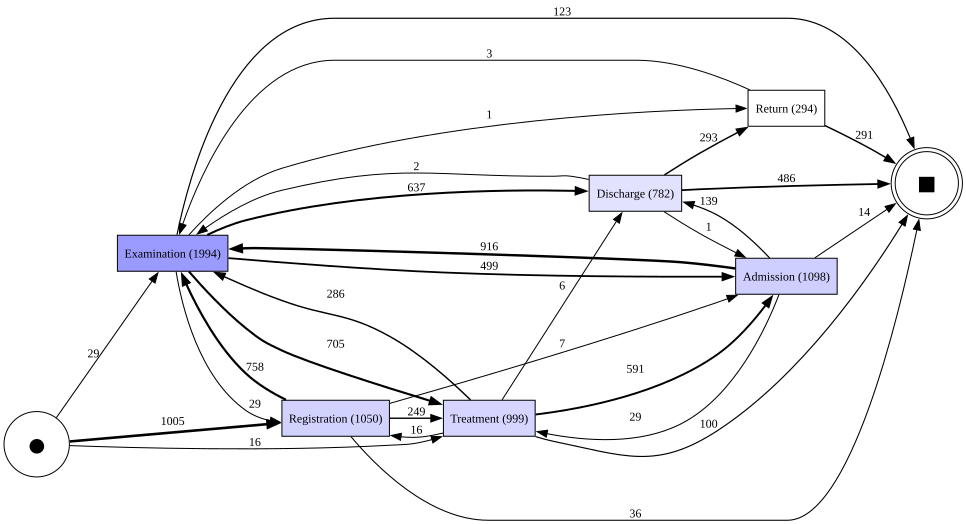

Рисунок сохранён: D:\Универ\4 курс\Диплом\sepsis_dfg.svg


In [2]:
import shutil
from pathlib import Path
from tempfile import TemporaryDirectory

import os
import matplotlib.pyplot as plt
import pandas as pd
import pm4py
from IPython.display import SVG, display
from pm4py.visualization.dfg import visualizer as dfg_visualizer

graphviz_dir = Path(
    r"C:\Program Files\Graphviz\bin"
)

graphviz = graphviz_dir / "dot.exe"

if not graphviz.is_file():
    raise FileNotFoundError(
        f"Не найден файл: {graphviz}"
    )

os.environ["PATH"] = (
    str(graphviz_dir)
    + os.pathsep
    + os.environ.get("PATH", "")
)

HAS_DOT = shutil.which("dot") is not None
print("PM4Py:", pm4py.__version__)
print("pandas:", pd.__version__)
print("Graphviz dot доступен:", HAS_DOT)


file_path = Path(
    r"D:\Универ\4 курс\Диплом\Sepsis Cases - Event Log_grouped_collapsed.csv"
)

events_table = pd.read_csv(
    file_path,
    sep=",",
    dtype=str,
    encoding="utf-8-sig",
    keep_default_na=False
)


required_columns = [
    "case_id",
    "event_group",
    "time:timestamp"
]

events_table = events_table[required_columns].copy()

if events_table.empty:
    raise ValueError("Журнал событий")

for column_name in required_columns:

    empty_values = events_table[column_name].str.strip() == ""
    if empty_values.any():
        raise ValueError(
            f"В столбце {column_name} есть пустые значения"
        )

events_table["time:timestamp"] = pd.to_datetime(
    events_table["time:timestamp"],
    format="mixed",
    utc=True,
    errors="raise"
)


events_table["source_order"] = range(len(events_table))

events_table = events_table.sort_values(
    by=["case_id", "time:timestamp", "source_order"],
    kind="stable"
)


event_log = pm4py.format_dataframe(
    events_table,
    case_id="case_id",
    activity_key="event_group",
    timestamp_key="time:timestamp"
)


#DFG, начальные и конечные действия

directly_follows_graph, starting_activities, ending_activities = (
    pm4py.discover_dfg(event_log)
)

transition_rows = []

for activity_pair, transition_count in directly_follows_graph.items():

    starting_group = activity_pair[0]
    following_group = activity_pair[1]

    transition_information = {
        "from_group": starting_group,
        "to_group": following_group,
        "transition_count": transition_count
    }

    transition_rows.append(transition_information)

transitions_table = pd.DataFrame(
    transition_rows,
    columns=["from_group", "to_group", "transition_count"]
)

transitions_table = transitions_table.sort_values(
    by="transition_count",
    ascending=False
)



print("Случаев:", events_table["case_id"].nunique())
print("Событий:", len(events_table))
print("Групп:", events_table["event_group"].nunique())
print("Различных связей:", len(transitions_table))

print()
print("Начальные группы:", starting_activities)
print("Последние группы:", ending_activities)

display(transitions_table)



transitions_file_path = (
    file_path.parent / "sepsis_dfg_transitions.csv"
)

transitions_table.to_csv(
    transitions_file_path,
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("Таблица связей сохранена:", transitions_file_path)


#Рисуем

if shutil.which("dot") is not None:

    visualization_parameters = {
        "start_activities": starting_activities,
        "end_activities": ending_activities,
        "format": "svg"
    }

    graph_visualization = dfg_visualizer.apply(
        directly_follows_graph,
        log=event_log,
        parameters=visualization_parameters
    )

    graph_svg = graph_visualization.pipe(
        format="svg"
    )

    display(SVG(graph_svg))


    image_file_path = (
        file_path.parent / "sepsis_dfg.svg"
    )

    image_file_path.write_bytes(graph_svg)

    print("Рисунок сохранён:", image_file_path)

else:

    print(
        "Не получатеся визуализировать"
    )

Без группировки:

PM4Py: 2.7.23.8
pandas: 3.0.6
Graphviz dot доступен: True
Случаев: 1050
Событий: 15214
Различных действий: 16
Различных связей: 115

Начальные группы: {'ER Registration': 995, 'ER Sepsis Triage': 7, 'CRP': 10, 'Leucocytes': 18, 'IV Liquid': 14, 'ER Triage': 6}
Последние группы: {'Release A': 393, 'IV Antibiotics': 87, 'Return ER': 291, 'LacticAcid': 24, 'Admission NC': 14, 'CRP': 41, 'ER Sepsis Triage': 49, 'Leucocytes': 44, 'IV Liquid': 12, 'Release B': 55, 'Release E': 5, 'Release C': 19, 'Release D': 14, 'ER Triage': 2}


,from_group,to_group,transition_count
93,Leucocytes,CRP,1778
28,CRP,Leucocytes,1445
37,ER Registration,ER Triage,971
52,ER Triage,ER Sepsis Triage,905
27,CRP,LacticAcid,629
...,...,...,...
106,Leucocytes,Return ER,1
110,Release B,Admission NC,1
108,Release A,Leucocytes,1
107,Release A,CRP,1


Таблица связей сохранена: D:\Универ\4 курс\Диплом\sepsis_dfg_orig_transitions.csv


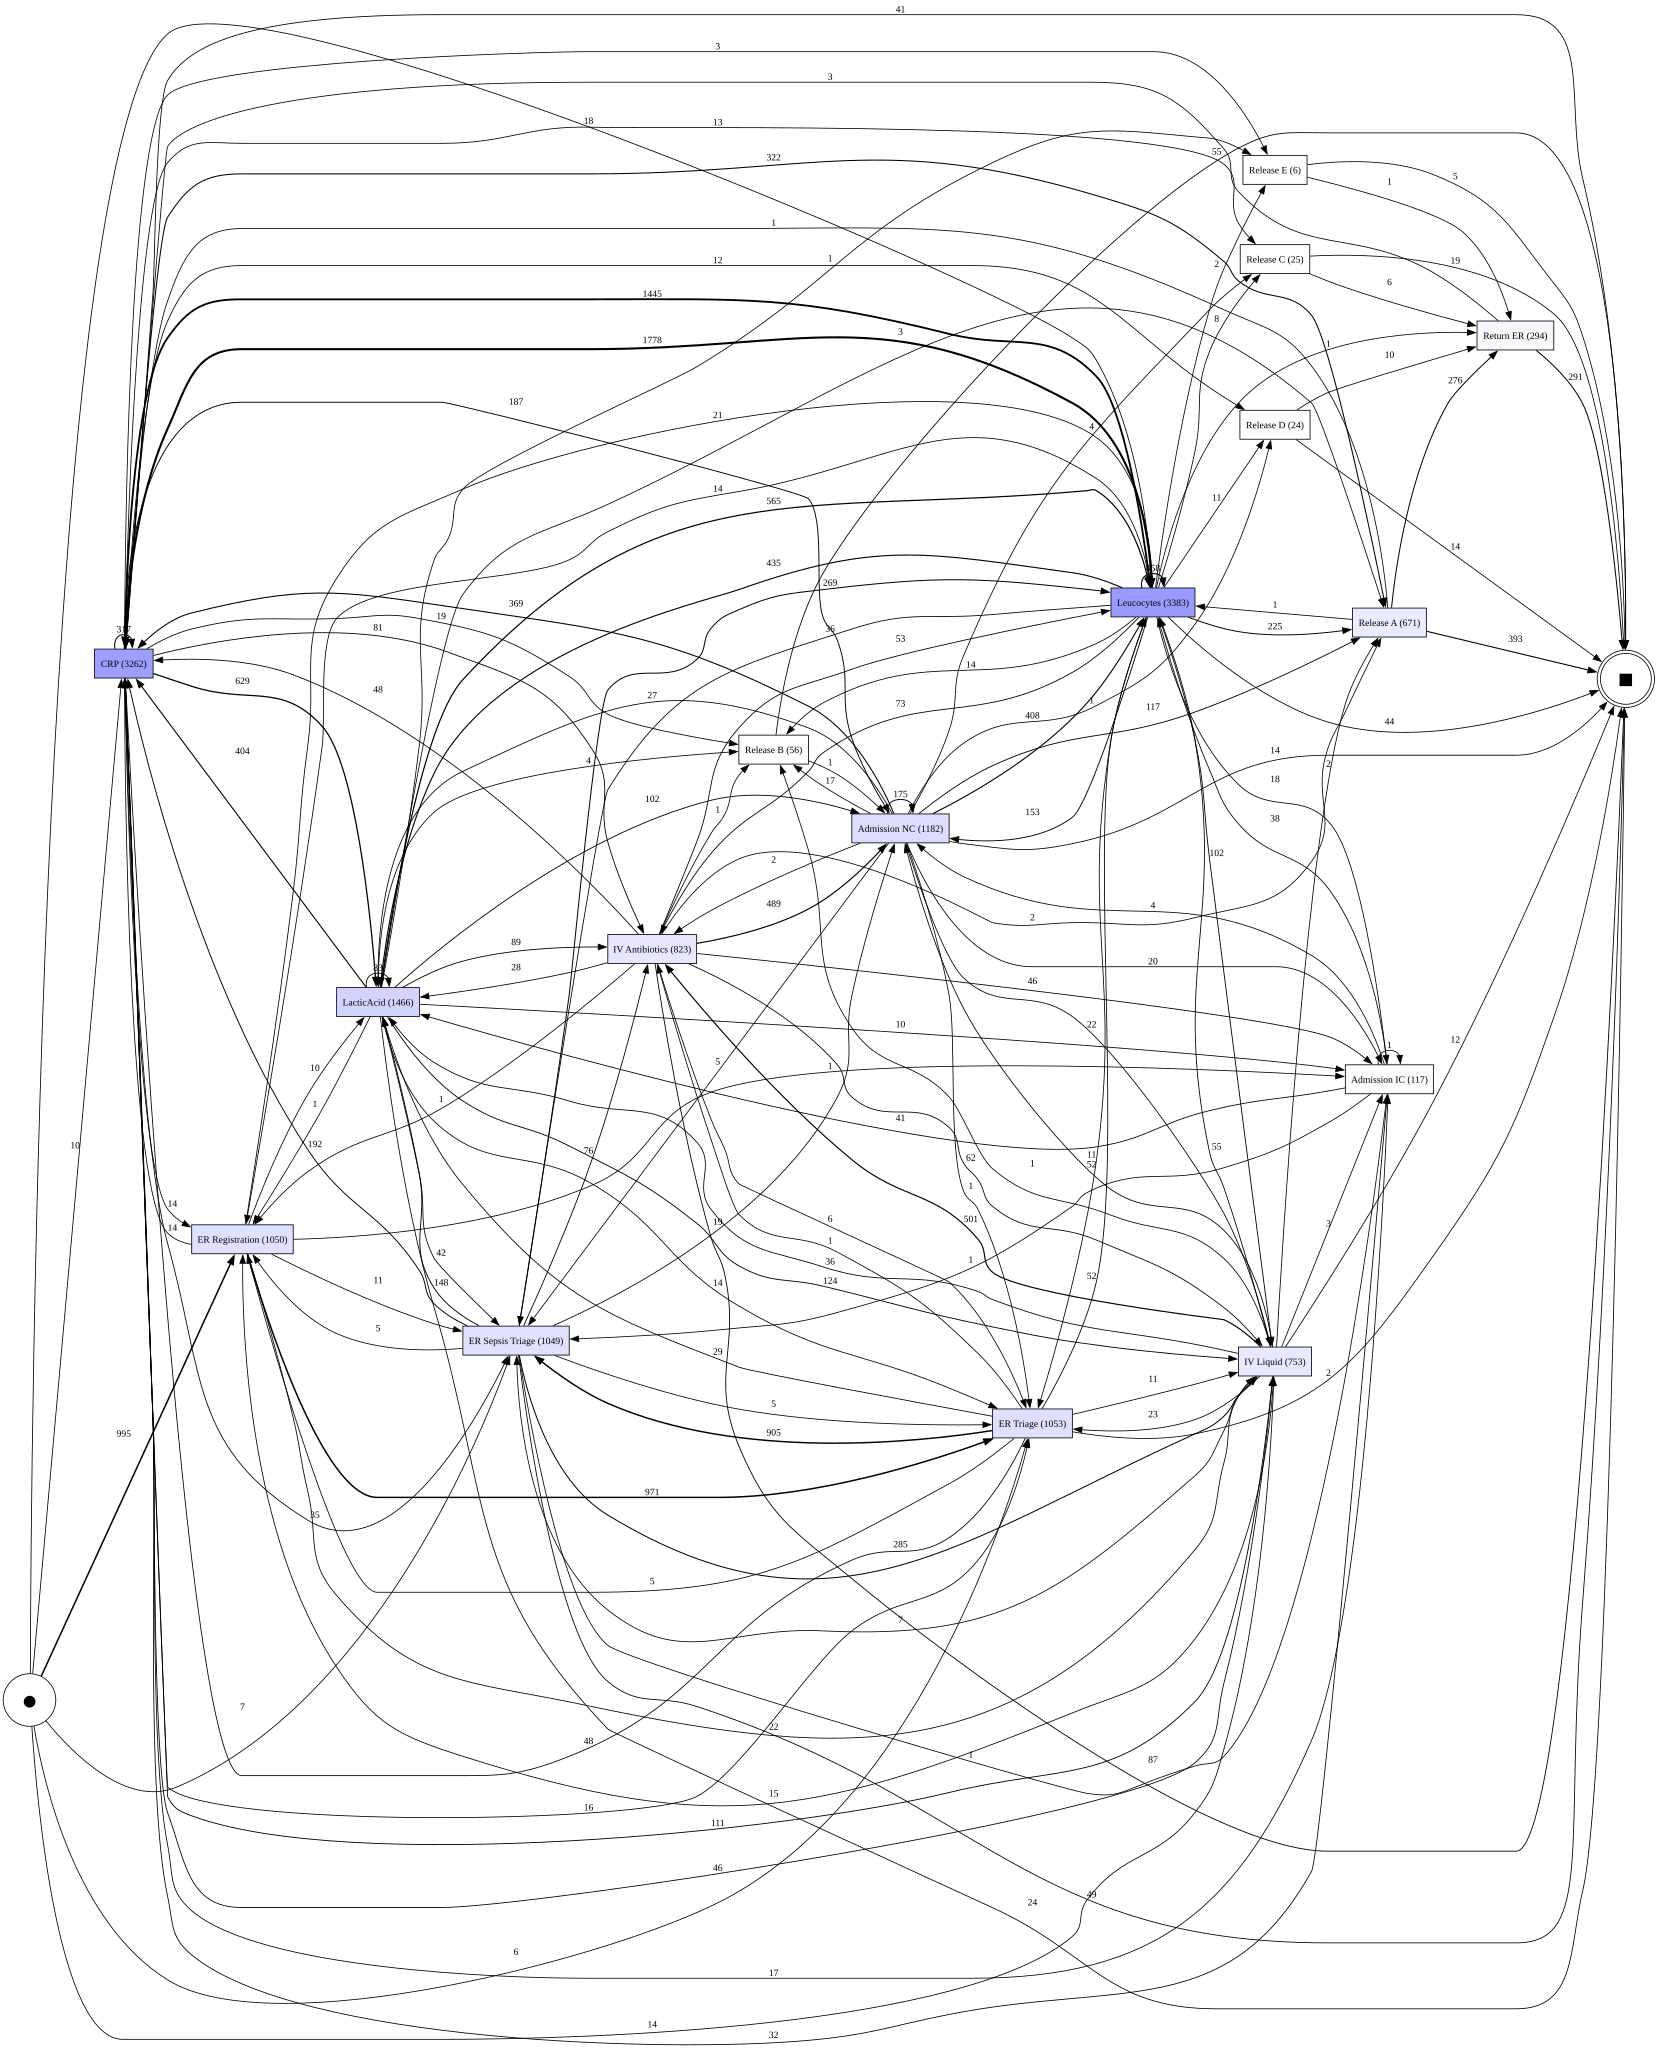

Рисунок сохранён: D:\Универ\4 курс\Диплом\sepsis_dfg_orig.svg


In [3]:
import shutil
from pathlib import Path
from tempfile import TemporaryDirectory

import os
import matplotlib.pyplot as plt
import pandas as pd
import pm4py
from IPython.display import SVG, display
from pm4py.visualization.dfg import visualizer as dfg_visualizer

graphviz_dir = Path(
    r"C:\Program Files\Graphviz\bin"
)

graphviz = graphviz_dir / "dot.exe"

if not graphviz.is_file():
    raise FileNotFoundError(
        f"Не найден файл: {graphviz}"
    )

os.environ["PATH"] = (
    str(graphviz_dir)
    + os.pathsep
    + os.environ.get("PATH", "")
)

HAS_DOT = shutil.which("dot") is not None
print("PM4Py:", pm4py.__version__)
print("pandas:", pd.__version__)
print("Graphviz dot доступен:", HAS_DOT)


file_path = Path(
    r"D:\Универ\4 курс\Диплом\Sepsis Cases - Event Log.csv"
)

events_table = pd.read_csv(
    file_path,
    sep=";",
    dtype=str,
    encoding="utf-8-sig",
    keep_default_na=False
)


required_columns = [
    "case_id",
    "concept:name",
    "time:timestamp"
]

events_table = events_table[required_columns].copy()

if events_table.empty:
    raise ValueError("Журнал событий")

for column_name in required_columns:

    empty_values = events_table[column_name].str.strip() == ""
    if empty_values.any():
        raise ValueError(
            f"В столбце {column_name} есть пустые значения"
        )

events_table["time:timestamp"] = pd.to_datetime(
    events_table["time:timestamp"],
    format="mixed",
    utc=True,
    errors="raise"
)


events_table["source_order"] = range(len(events_table))

events_table = events_table.sort_values(
    by=["case_id", "time:timestamp", "source_order"],
    kind="stable"
)


event_log = pm4py.format_dataframe(
    events_table,
    case_id="case_id",
    activity_key="concept:name",
    timestamp_key="time:timestamp"
)


#DFG, начальные и конечные действия

directly_follows_graph, starting_activities, ending_activities = (
    pm4py.discover_dfg(event_log)
)

transition_rows = []

for activity_pair, transition_count in directly_follows_graph.items():

    starting_group = activity_pair[0]
    following_group = activity_pair[1]

    transition_information = {
        "from_group": starting_group,
        "to_group": following_group,
        "transition_count": transition_count
    }

    transition_rows.append(transition_information)

transitions_table = pd.DataFrame(
    transition_rows,
    columns=["from_group", "to_group", "transition_count"]
)

transitions_table = transitions_table.sort_values(
    by="transition_count",
    ascending=False
)



print("Случаев:", events_table["case_id"].nunique())
print("Событий:", len(events_table))
print("Различных действий:", events_table["concept:name"].nunique())
print("Различных связей:", len(transitions_table))

print()
print("Начальные группы:", starting_activities)
print("Последние группы:", ending_activities)

display(transitions_table)



transitions_file_path = (
    file_path.parent / "sepsis_dfg_orig_transitions.csv"
)

transitions_table.to_csv(
    transitions_file_path,
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("Таблица связей сохранена:", transitions_file_path)


#Рисуем

if shutil.which("dot") is not None:

    visualization_parameters = {
        "start_activities": starting_activities,
        "end_activities": ending_activities,
        "format": "svg"
    }

    graph_visualization = dfg_visualizer.apply(
        directly_follows_graph,
        log=event_log,
        parameters=visualization_parameters
    )

    graph_svg = graph_visualization.pipe(
        format="svg"
    )

    display(SVG(graph_svg))


    image_file_path = (
        file_path.parent / "sepsis_dfg_orig.svg"
    )

    image_file_path.write_bytes(graph_svg)

    print("Рисунок сохранён:", image_file_path)

else:

    print(
        "Не получатеся визуализировать"
    )

# Вопросы:

1) Что считать одним случаем и началом времени? Один case_id из журнала? Время отсчитывать от первого зарегистрированного события или только от регистрации в приёмном отделении? Как учитывать Return ER в том же случае?

2) Оставить для начала вариант с группировкой или без?

3) Смерть на рандом проставить?
